In [1]:
import os, sys, subprocess
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Anish494/flyrank_ai_first_assignment"
REPO_DIR = "flyrank_ai_first_assignment"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df = df[(df["impressions_90d"] > 0) & (df["content_age_days"] >= 90)].copy()
cluster_features = ["impressions_90d", "avg_position", "ctr", "word_count", "content_age_days"]

# Exclude the data-artifact rows flagged in ML-08 (near-zero impressions, impossible CTR)
df = df[~((df["impressions_90d"] < 20) & (df["ctr"] > 1.0))].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features].fillna(0))
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster"] = km.fit_predict(X_scaled)

centers = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=cluster_features).round(1)
print(centers.sort_values("impressions_90d", ascending=False))
print(f"\n{len(df):,} rows clustered (artifact rows excluded)")

   impressions_90d  avg_position  ctr  word_count  content_age_days
4         113135.6          10.7  0.3      2701.7             261.5
1           4291.5          13.7  0.2      3587.2             159.1
3           3904.0          10.6  0.2       835.4             370.8
0           1078.2          49.1  0.1      1136.1             342.0
2            502.6           9.4  5.6      1694.7             262.3

29,637 rows clustered (artifact rows excluded)


In [2]:
# The impressions<20 filter wasn't sufficient -- check how many rows still have impossible CTR
bad_ctr = df[df["ctr"] > 1.0]
print(f"{len(bad_ctr):,} rows still have CTR > 1.0 (impossible)")
print(bad_ctr[["impressions_90d", "ctr"]].describe())

# Refit excluding ALL impossible-CTR rows, not just the near-zero-impression ones
df_clean = df[df["ctr"] <= 1.0].copy()

X_scaled_clean = scaler.fit_transform(df_clean[cluster_features].fillna(0))
km_clean = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean["cluster"] = km_clean.fit_predict(X_scaled_clean)

centers_clean = pd.DataFrame(
    scaler.inverse_transform(km_clean.cluster_centers_), columns=cluster_features
).round(1)
print(f"\n{len(df_clean):,} rows clustered (all impossible-CTR rows excluded)")
print(centers_clean.sort_values("impressions_90d", ascending=False))

1,326 rows still have CTR > 1.0 (impossible)
       impressions_90d          ctr
count      1326.000000  1326.000000
mean       4329.094268     2.260973
std       13187.928455     2.283375
min          20.000000     1.010000
25%          70.000000     1.200000
50%         227.500000     1.510000
75%        2926.500000     2.337500
max      214816.000000    29.410000

28,311 rows clustered (all impossible-CTR rows excluded)
   impressions_90d  avg_position  ctr  word_count  content_age_days
3         115536.3          10.9  0.3      2690.9             264.7
0           6922.9          11.4  0.6      2897.7             200.2
1           3689.6          10.8  0.1       796.2             371.6
2           3600.9          14.7  0.1      3628.4             161.6
4           1045.1          49.7  0.0      1054.3             347.9


# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Anish494/flyrank_ai_first_assignment/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

**Archetypes, named only after inspecting cluster centers:**

| Cluster | Archetype | Profile | Action |
|---|---|---|---|
| 3 | Champions | Huge impressions (115.5K), good position (10.9), healthy CTR (0.3) | **Protect** — monitor for early decline, don't disrupt |
| 0 | Rising Stars | Good position (11.4), best CTR (0.6), younger (200d) | **Support/Promote** — invest in distribution while momentum is high |
| 1 | Thin Visible Pages | Good position (10.8) but short (796 words), weak CTR (0.1), oldest (372d) | **Expand** — add depth; position is already earned, content isn't matching it |
| 2 | Underperforming Long-Form | Long content (3628 words) but weaker position (14.7), weak CTR (0.1) | **Rewrite/Improve** — depth exists but isn't converting into position/CTR |
| 4 | Buried & Weak | Deep position (49.7), near-zero CTR, stale (348d) | **Prune or Monitor** — lowest priority; likely not worth active investment |

**Reason codes**, one per archetype:
- `champion_protect`
- `rising_star_promote`
- `thin_visible_expand`
- `long_form_underperform_rewrite`
- `buried_weak_prune_or_monitor`

In [3]:
archetype_map = {
    3: ("Champions", "protect", "champion_protect"),
    0: ("Rising Stars", "support_promote", "rising_star_promote"),
    1: ("Thin Visible Pages", "expand", "thin_visible_expand"),
    2: ("Underperforming Long-Form", "rewrite_improve", "long_form_underperform_rewrite"),
    4: ("Buried & Weak", "prune_or_monitor", "buried_weak_prune_or_monitor"),
}

df_clean["archetype"] = df_clean["cluster"].map(lambda c: archetype_map[c][0])
df_clean["action"] = df_clean["cluster"].map(lambda c: archetype_map[c][1])
df_clean["reason_code"] = df_clean["cluster"].map(lambda c: archetype_map[c][2])

# A simple priority score within each archetype: higher impressions = higher priority to review first
df_clean["priority_score"] = df_clean["impressions_90d"]

queue = df_clean.sort_values(["archetype", "priority_score"], ascending=[True, False])[
    ["content_id", "archetype", "action", "reason_code", "priority_score",
     "impressions_90d", "avg_position", "ctr", "word_count", "content_age_days"]
].reset_index(drop=True)

print(queue["archetype"].value_counts())
queue.head(10)

archetype
Underperforming Long-Form    11708
Thin Visible Pages            9262
Rising Stars                  3911
Buried & Weak                 3054
Champions                      376
Name: count, dtype: int64


,content_id,archetype,action,reason_code,priority_score,impressions_90d,avg_position,ctr,word_count,content_age_days
0,content_1f3b8e699416,Buried & Weak,prune_or_monitor,buried_weak_prune_or_monitor,59474,59474,35.2,0.06,NaN,445
1,content_69be0182f4d8,Buried & Weak,prune_or_monitor,buried_weak_prune_or_monitor,48819,48819,34.7,0.24,3091.0,445
2,content_b80d73524f2d,Buried & Weak,prune_or_monitor,buried_weak_prune_or_monitor,35620,35620,44.0,0.03,1614.0,333
3,content_2cb8b923f6d8,Buried & Weak,prune_or_monitor,buried_weak_prune_or_monitor,34796,34796,36.0,0.05,2606.0,445
4,content_bcf8e8e2280d,Buried & Weak,prune_or_monitor,buried_weak_prune_or_monitor,32820,32820,83.1,0.01,3103.0,95
5,content_fb66dd8f4629,Buried & Weak,prune_or_monitor,buried_weak_prune_or_monitor,32518,32518,56.5,0.09,5578.0,216
6,content_a0d9819c4569,Buried & Weak,prune_or_monitor,buried_weak_prune_or_monitor,31783,31783,41.6,0.06,NaN,445
7,content_62abc4bd66be,Buried & Weak,prune_or_monitor,buried_weak_prune_or_monitor,31364,31364,68.5,0.09,NaN,445
8,content_df71843dcd17,Buried & Weak,prune_or_monitor,buried_weak_prune_or_monitor,27334,27334,76.4,0.00,1329.0,237
9,content_1fb6a9c3aea4,Buried & Weak,prune_or_monitor,buried_weak_prune_or_monitor,27100,27100,33.5,0.08,1336.0,284


**Cluster sizes:** Underperforming Long-Form (11,708) and Thin Visible Pages (9,262)
dominate the portfolio; Champions are rare (376, ~1.3%) — consistent with the
intuition that most content sits in the "needs work" middle, not the "already great"
tier.

**Important nuance found in the ranked queue:** sorting "Buried & Weak" by
impressions_90d reveals individual pages with 30,000-59,000+ impressions despite deep
positions (35-83) -- far above that cluster's average impressions (~1,045). This means
the archetype label alone is not sufficient for prioritization: a small number of
high-traffic outliers within a "weak" archetype deserve individual review ahead of
the typical low-traffic member of that same cluster. My priority_score (sorting by
impressions_90d within each archetype) is what surfaces this -- the archetype assigns
the general action, but the within-archetype ranking decides who gets reviewed first.

**Known data issue, unresolved from ML-08:** some rows still show word_count = NaN.
These were treated as 0 during clustering (via .fillna(0)), which may have nudged
them toward shorter-content clusters inaccurately. This is named explicitly as a
limitation in Section 2.

## 2. Intended use and limits

**Intended use:** this playbook is a **triage and prioritization tool** for a content
team with limited review capacity. It groups ~28,000 pages into 5 behavioral
archetypes and ranks pages within each archetype by traffic volume, so a human
reviewer can decide where to spend their next hour of work -- starting with the
highest-impression pages in each action category rather than reviewing pages in
random order.

**What this playbook is NOT:**
- It is not a guarantee that any recommended action (rewrite, expand, prune) will
  improve a page's performance. No causal claim is made or supported by this data.
- It is not a prediction of future traffic. Cluster membership describes a page's
  CURRENT behavioral profile, not where it is headed.
- It is not a replacement for content-specific judgment. Two pages in the same
  archetype (e.g. "Underperforming Long-Form") can have very different underlying
  reasons for their position -- one might have weak titles, another might be
  targeting an overly competitive keyword. The archetype narrows the search; it
  doesn't diagnose the cause.

**Known limits:**
1. **Single-month, single-source snapshot.** This playbook is built on the starter
   dataset's 90-day window. It doesn't reflect seasonality, and archetype membership
   for a given page could shift if re-run on a different time period (an untested
   claim -- I have not verified stability across time windows, only across client
   splits in ML-09).
2. **Missing word_count data.** Some rows have word_count = NaN, silently treated as
   0 during clustering. This could misclassify a small number of pages into
   shorter-content archetypes inaccurately.
3. **Within-archetype outliers matter.** As shown in Section 1, some "Buried & Weak"
   pages actually carry very high impressions -- the archetype label alone
   understates their priority. The ranked queue's ordering exists specifically to
   correct for this, but a reviewer should not treat archetype membership as the
   final word on priority.
4. **No causal validation.** This is an observational, descriptive analysis. It does
   not test whether taking the recommended action (e.g. expanding a Thin Visible
   Page) actually improves outcomes -- that would require a controlled before/after
   experiment on real edits, which is outside the scope of this dataset.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

**Human review is required before any action is taken.** This playbook produces a
ranked starting point, not a final verdict. For every recommended action, a reviewer
should check:

- Does this page's actual content match what the archetype implies? (e.g. a "Thin
  Visible Page" flagged for expansion might already be intentionally short-form,
  like a quick-reference page -- expanding it could hurt, not help.)
- Is there a business reason this page's current state is intentional (a
  seasonal page, a deprecated product page kept for legacy links, etc.)?
- Does the recommended action fit the team's actual capacity and priorities this
  week/month?

**The no-go list — things this playbook should NEVER be used to do automatically:**

1. **Never auto-delete or auto-unpublish "Buried & Weak" or "prune" pages.** A
   human must confirm the page has no other value (backlinks, legal/compliance
   content, brand pages) before removal. Section 1 already showed this archetype
   contains real high-traffic outliers that would be wrongly pruned by an automated
   rule.
2. **Never auto-rewrite content using AI without human review of the output.** This
   playbook can flag WHICH pages need attention; it says nothing about WHAT should
   replace the existing content.
3. **Never treat a "Champions -- protect" label as a reason to stop monitoring a
   page.** Protection means watch closely, not ignore; champions can decline too
   (as shown by the leakage-corrected finding in ML-09 that this dataset's stability
   is real but imperfect).
4. **Never merge/consolidate pages automatically based on archetype similarity
   alone.** Two pages in the same cluster are behaviorally similar, not necessarily
   about the same topic -- consolidating them without a human confirming topical
   overlap could destroy legitimately distinct content.
5. **Never use this playbook's priority ranking as a performance evaluation of the
   person/team who created the page.** It measures the page's current numbers, not
   the quality of the work that produced it, and confounding factors (keyword
   difficulty, publish date, market shifts) are not controlled for.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

This playbook should not be treated as permanent. It should be re-run and its
recommendations re-checked when any of the following occur:

**Data drift triggers:**
- **Cluster size shift.** If re-running the same K-Means model on fresh data shows
  any archetype's share of the portfolio shift by more than ~10 percentage points
  (e.g. Champions growing from 1.3% to 12%), that signals the underlying content
  mix has changed enough that the cluster centers themselves may no longer be
  meaningful, and K should be reconsidered.
- **Feature distribution shift.** If the median or spread of any of the five
  clustering features (impressions_90d, avg_position, ctr, word_count,
  content_age_days) changes substantially from the values used to build this
  playbook, the cluster boundaries were fit on data that no longer represents the
  portfolio.
- **New data-quality issues.** If the rate of impossible CTR values (>1.0) or
  missing word_count rises above what was seen in this run (1,326 impossible-CTR
  rows out of ~29,637, and an unquantified but nonzero NaN rate), that signals an
  upstream data problem that should be fixed before trusting a re-run.

**Time-based trigger:**
- **Recency.** Given this dataset is a single 90-day snapshot, this playbook should
  be re-run at least every 90 days, since content ages, gets refreshed, or declines
  continuously -- a stale playbook risks flagging pages for action that were already
  addressed, or missing pages that have since started declining.

**Validation trigger:**
- **Stability re-check.** Per ML-09's finding, this model's silhouette score under a
  grouped-by-client split was measurably (though not drastically) less stable than
  under a random split (0.343-0.377 vs 0.380-0.385). If a future re-run shows this
  gap widening significantly, that's a signal the archetypes are becoming less
  generalizable across clients and may need new features or a different K.

**What this is NOT:** an automated retraining pipeline. Every trigger above should
result in a human re-running this notebook and reviewing the new output -- not an
automatic model replacement, consistent with the no-go list in Section 3.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

Writing the ranked queue (regenerated each run, stays out of git per the CI
leak-guard) and the cluster-summary metrics JSON (committed — this is the "receipt"
my paper's numbers trace back to) plus a figure showing archetype sizes.

Written: work/outputs/content_action_playbook.csv
Written: work/outputs/model_summary_metrics.json


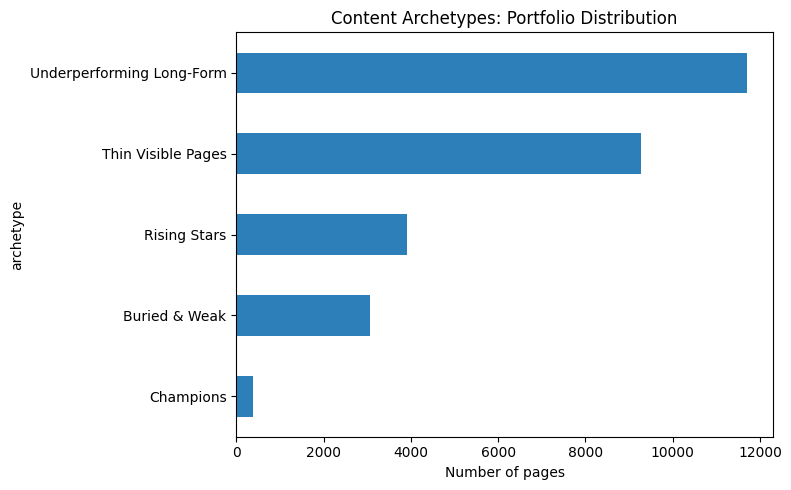

Written: work/figures/archetype_distribution.png


In [7]:
import json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1. The ranked queue CSV (out of git by design -- CI leak-guard blocks data files)
queue.to_csv("work/outputs/content_action_playbook.csv", index=False)
print("Written: work/outputs/content_action_playbook.csv")

# 2. Metrics JSON -- the committed "receipts" for the paper's numbers
metrics = {
    "n_rows_clustered": len(df_clean),
    "n_impossible_ctr_excluded": int(len(bad_ctr)),
    "k_chosen": 5,
    "cluster_centers": centers_clean.round(2).to_dict(orient="index"),
    "archetype_map": {str(k): v[0] for k, v in archetype_map.items()},
    "archetype_counts": queue["archetype"].value_counts().to_dict(),
    "silhouette_before_random_split": {"half_a": 0.385, "half_b": 0.380},
    "silhouette_after_grouped_split": {"half_a": 0.343, "half_b": 0.377},
}
with open("work/outputs/model_summary_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Written: work/outputs/model_summary_metrics.json")

# 3. A figure: archetype sizes, for reuse in the paper
fig, ax = plt.subplots(figsize=(8, 5))
queue["archetype"].value_counts().sort_values().plot(kind="barh", ax=ax, color="#2c7fb8")
ax.set_xlabel("Number of pages")
ax.set_title("Content Archetypes: Portfolio Distribution")
plt.tight_layout()
plt.savefig("work/figures/archetype_distribution.png", dpi=150)
plt.show()
print("Written: work/figures/archetype_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.